In [1]:
import pandas as pd
import numpy as np

# Load the dataset
reviews = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')

print(f"Shape: {reviews.shape}")
print(f"\nColumns: {reviews.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(reviews.head(3))

Shape: (23486, 11)

Columns: ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

First 3 rows:
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   

   Positive Feedback Count Division Name Department Name Class Name  
0                        0     Initmates        Intimate  Intimates  
1                        4       General         Dresses    Dresses  
2            

In [2]:
reviews.info()


<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


In [3]:
# Drop rows with missing review text
reviews = reviews.dropna(subset=['Review Text']).reset_index(drop=True)

# Our features (X) and labels (y)
X_reviews = reviews['Review Text']
y_reviews = reviews['Recommended IND']

# Check class balance
print(f"Total reviews: {len(reviews)}")
print(f"\nClass distribution:")
print(y_reviews.value_counts())
print(f"\nRecommend rate: {y_reviews.mean():.1%}")

# Show a positive and negative example
print("\n--- Positive example ---")
print(reviews[reviews['Recommended IND']==1]['Review Text'].iloc[0][:200])
print("\n--- Negative example ---")
print(reviews[reviews['Recommended IND']==0]['Review Text'].iloc[0][:200])

Total reviews: 22641

Class distribution:
Recommended IND
1    18540
0     4101
Name: count, dtype: int64

Recommend rate: 81.9%

--- Positive example ---
Absolutely wonderful - silky and sexy and comfortable

--- Negative example ---
I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could 


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split into train and test (stratified)
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    X_reviews, y_reviews, test_size=0.2, random_state=42, stratify=y_reviews
)

# TF-IDF: converts text into numerical features
vectorizer = TfidfVectorizer(
    max_features=5000,      # keep top 5000 words
    stop_words='english',   # ignore "the", "is", "and", etc.
    ngram_range=(1, 2)      # use single words AND pairs ("not good")
)

X_train_tfidf = vectorizer.fit_transform(X_train_txt)
X_test_tfidf = vectorizer.transform(X_test_txt)

print(f"Training set: {X_train_tfidf.shape}")
print(f"Test set: {X_test_tfidf.shape}")
print(f"Number of features (words/phrases): {X_train_tfidf.shape[1]}")

Training set: (18112, 5000)
Test set: (4529, 5000)
Number of features (words/phrases): 5000


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

# Model 1: Logistic Regression (usually the best for TF-IDF text)
text_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
text_lr.fit(X_train_tfidf, y_train_txt)

# Model 2: Random Forest
text_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
text_rf.fit(X_train_tfidf, y_train_txt)

print("Both models trained!")

Both models trained!


In [6]:
for name, m in [('Logistic Regression', text_lr), ('Random Forest', text_rf)]:
    y_pred = m.predict(X_test_tfidf)
    y_proba = m.predict_proba(X_test_tfidf)[:, 1]
    print(f"\n=== {name} ===")
    print(classification_report(y_test_txt, y_pred))
    print(f"F1: {f1_score(y_test_txt, y_pred):.3f}")
    print(f"AUC: {roc_auc_score(y_test_txt, y_proba):.3f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.59      0.82      0.69       820
           1       0.96      0.87      0.91      3709

    accuracy                           0.86      4529
   macro avg       0.77      0.85      0.80      4529
weighted avg       0.89      0.86      0.87      4529

F1: 0.913
AUC: 0.926

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.77      0.33      0.47       820
           1       0.87      0.98      0.92      3709

    accuracy                           0.86      4529
   macro avg       0.82      0.66      0.69      4529
weighted avg       0.85      0.86      0.84      4529

F1: 0.920
AUC: 0.906


              Model  Accuracy  F1 (weighted)  Negative Recall  Negative Precision   AUC
Logistic Regression     0.864          0.872            0.821               0.589 0.926
      Random Forest     0.862          0.838            0.334               0.772 0.906


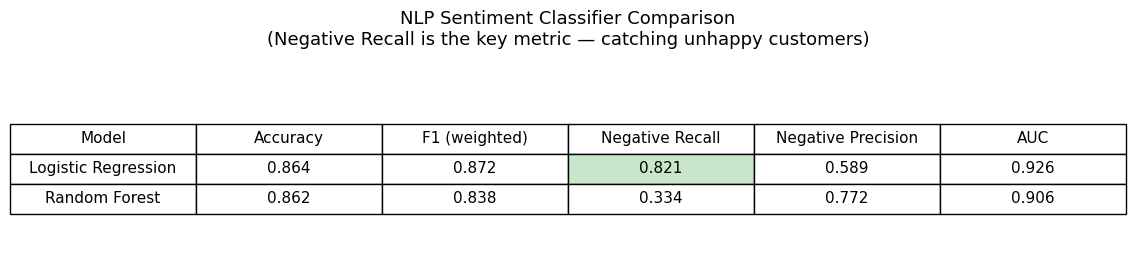


NLP comparison saved as CSV and PNG!


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# Build the NLP comparison table
nlp_results = []
for name, m in [('Logistic Regression', text_lr), ('Random Forest', text_rf)]:
    y_pred = m.predict(X_test_tfidf)
    y_proba = m.predict_proba(X_test_tfidf)[:, 1]
    nlp_results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test_txt, y_pred), 3),
        'F1 (weighted)': round(f1_score(y_test_txt, y_pred, average='weighted'), 3),
        'Negative Recall': round(recall_score(y_test_txt, y_pred, pos_label=0), 3),
        'Negative Precision': round(precision_score(y_test_txt, y_pred, pos_label=0), 3),
        'AUC': round(roc_auc_score(y_test_txt, y_proba), 3)
    })

nlp_comparison = pd.DataFrame(nlp_results)
print(nlp_comparison.to_string(index=False))

# Save as CSV
nlp_comparison.to_csv('models/nlp_comparison.csv', index=False)

# Save as image for README
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')
table = ax.table(
    cellText=nlp_comparison.values,
    colLabels=nlp_comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Highlight the winning model (Logistic Regression) in the Negative Recall column
table[(1, 3)].set_facecolor('#c8e6c9')  # green highlight

plt.title('NLP Sentiment Classifier Comparison\n(Negative Recall is the key metric — catching unhappy customers)',
          fontsize=13, pad=20)
plt.savefig('plots/nlp_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nNLP comparison saved as CSV and PNG!")

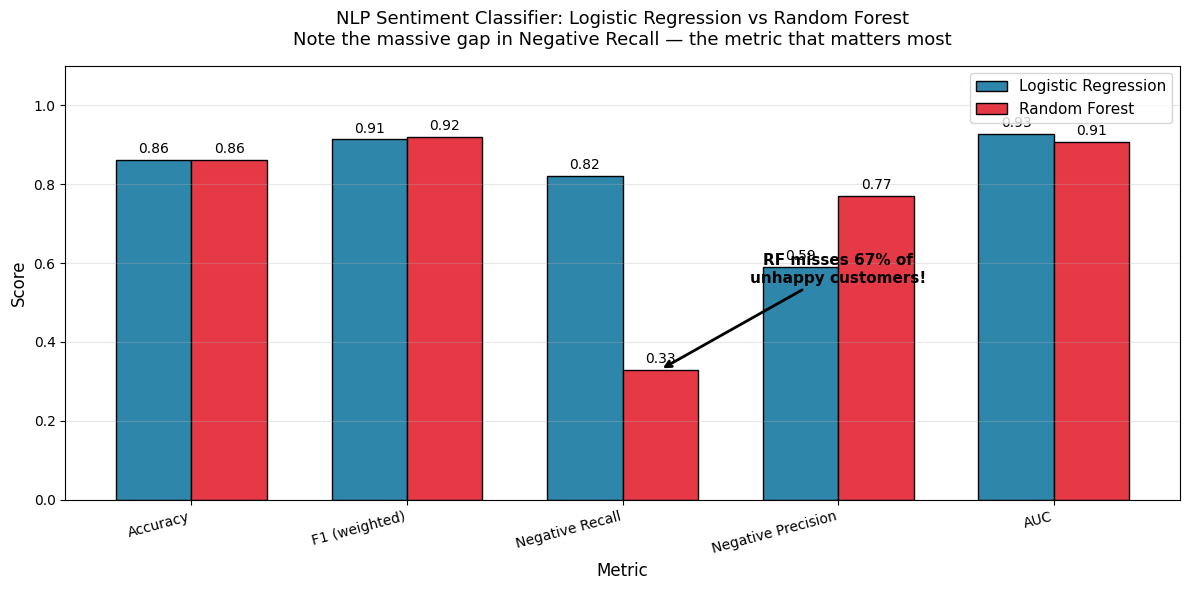

Saved to plots/nlp_model_comparison.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to compare
metrics = ['Accuracy', 'F1 (weighted)', 'Negative Recall', 'Negative Precision', 'AUC']
lr_scores = [0.86, 0.913, 0.82, 0.59, 0.926]
rf_scores = [0.86, 0.920, 0.33, 0.77, 0.906]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#2E86AB', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',
               color='#E63946', edgecolor='black')

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('NLP Sentiment Classifier: Logistic Regression vs Random Forest\n' +
             'Note the massive gap in Negative Recall — the metric that matters most',
             fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Highlight the key insight with an annotation
ax.annotate('RF misses 67% of\nunhappy customers!',
            xy=(2 + width/2, 0.33), xytext=(3, 0.55),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=11, color='black', fontweight='bold',
            ha='center')

plt.tight_layout()
plt.savefig('plots/nlp_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to plots/nlp_model_comparison.png")

In [13]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save the NLP model and vectorizer
joblib.dump(text_lr, 'models/text_classifier_linerR.joblib')
joblib.dump(text_rf, 'models/text_classifier_RF.joblib')
joblib.dump(vectorizer, 'models/tfidf_vectorizer.joblib')

print("NLP models saved!")
print("\nFiles in models/ folder:")
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f} ({size:.1f} KB)")

NLP models saved!

Files in models/ folder:
  .ipynb_checkpoints (0.1 KB)
  churn_gbc.joblib (186.6 KB)
  churn_lr.joblib (2.2 KB)
  churn_nn.pth (18.8 KB)
  churn_rf.joblib (6913.1 KB)
  model_comparison.csv (0.3 KB)
  nlp_comparison.csv (0.2 KB)
  scaler.joblib (2.3 KB)
  text_classifier.joblib (39.9 KB)
  text_classifier_RF.joblib (37656.1 KB)
  text_classifier_linerR.joblib (39.9 KB)
  tfidf_vectorizer.joblib (191.1 KB)
